# 01. Очистка данных

**Pipeline:** Загрузка CSV → Исправление геометрий → Фильтрация аномалий → Сохранение в parquet

**Параметры** настраиваются в ячейке конфига ниже и в `utils.py:CONFIG`

In [1]:
# ============================================================
# КОНФИГ — менять параметры здесь для тестирования гипотез
# ============================================================

from utils import CONFIG

# Переопределяем параметры при необходимости:
# CONFIG['min_area_a'] = 15.0  # попробовать другой порог
# CONFIG['spb_bbox']['lon_min'] = 29.5  # сузить bbox

print("Текущие параметры очистки:")
print(f"  min_area_a: {CONFIG['min_area_a']} м²")
print(f"  SPb bbox: {CONFIG['spb_bbox']}")
print(f"  max_height_b: {CONFIG['max_height_b']} м")

Текущие параметры очистки:
  min_area_a: 8.0 м²
  SPb bbox: {'lon_min': 29.4, 'lon_max': 30.8, 'lat_min': 59.6, 'lat_max': 60.2}
  max_height_b: 500.0 м


In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import (
    load_source_a, load_source_b,
    clean_source_a, clean_source_b,
    save_gdf, CONFIG
)

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

## 1. Загрузка данных

In [3]:
%%time
print("Загрузка Источника А...")
gdf_a = load_source_a()
print(f"  Загружено: {len(gdf_a)} записей, CRS: {gdf_a.crs}")

print("\nЗагрузка Источника Б...")
gdf_b = load_source_b()
print(f"  Загружено: {len(gdf_b)} записей, CRS: {gdf_b.crs}")

Загрузка Источника А...
  Загружено: 171454 записей, CRS: EPSG:4326

Загрузка Источника Б...


/Users/miptcapybara/Documents/PROJECTS/CupIT Final/utils.py:68: DtypeWarning: Columns (0: housing) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


  Загружено: 161076 записей, CRS: EPSG:4326
CPU times: user 1.65 s, sys: 90.8 ms, total: 1.74 s
Wall time: 1.77 s


## 2. Очистка

In [4]:
%%time
gdf_a_clean = clean_source_a(gdf_a)

=== Очистка Источника А ===
  [А] MULTIPOLYGON: 281 -> explode


/Users/miptcapybara/Documents/PROJECTS/CupIT Final/utils.py:110: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mask = gdf.geometry.area == 0


  [А] Площадь < 8.0 м²: 5705 -> удалены
  [А] Итого: 171454 -> 166111 (5343 удалено)
CPU times: user 584 ms, sys: 70.1 ms, total: 654 ms
Wall time: 667 ms


In [5]:
%%time
gdf_b_clean = clean_source_b(gdf_b)

=== Очистка Источника Б ===
  [Б] MULTIPOLYGON: 7 -> explode


/Users/miptcapybara/Documents/PROJECTS/CupIT Final/utils.py:110: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mask = gdf.geometry.area == 0
/Users/miptcapybara/Documents/PROJECTS/CupIT Final/utils.py:171: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  [Б] За пределами bbox СПб: 0 -> удалены
  [Б] Итого: 161076 -> 161085 (-9 удалено)
CPU times: user 454 ms, sys: 33.6 ms, total: 487 ms
Wall time: 489 ms


## 3. Валидация очистки

In [6]:
print("=== Валидация после очистки ===")
print(f"\nИсточник А: {len(gdf_a_clean)} записей")
print(f"  Невалидных геометрий: {(~gdf_a_clean.geometry.is_valid).sum()}")
print(f"  Пустых геометрий: {gdf_a_clean.geometry.is_empty.sum()}")
print(f"  MultiPolygon: {(gdf_a_clean.geometry.geom_type == 'MultiPolygon').sum()}")
print(f"  Площадь: min={gdf_a_clean['area_m2'].min():.1f}, median={gdf_a_clean['area_m2'].median():.1f}, max={gdf_a_clean['area_m2'].max():.1f} м²")
print(f"  Теги (топ-5): {gdf_a_clean['tag_main'].value_counts().head().to_dict()}")

print(f"\nИсточник Б: {len(gdf_b_clean)} записей")
print(f"  Невалидных геометрий: {(~gdf_b_clean.geometry.is_valid).sum()}")
print(f"  Пустых геометрий: {gdf_b_clean.geometry.is_empty.sum()}")
print(f"  MultiPolygon: {(gdf_b_clean.geometry.geom_type == 'MultiPolygon').sum()}")
print(f"  Высота: min={gdf_b_clean['height'].min():.1f}, median={gdf_b_clean['height'].median():.1f}, max={gdf_b_clean['height'].max():.1f} м")
print(f"  Высота пропущена: {gdf_b_clean['height'].isna().sum()}")

=== Валидация после очистки ===

Источник А: 166111 записей


  Невалидных геометрий: 0
  Пустых геометрий: 0
  MultiPolygon: 0
  Площадь: min=8.1, median=129.1, max=137682.7 м²
  Теги (топ-5): {'жилое здание': 57312, 'постройка': 45513, 'промышленность': 22405, 'Комплекс зданий': 8352, 'бизнес и услуги': 7544}

Источник Б: 161085 записей
  Невалидных геометрий: 0
  Пустых геометрий: 0
  MultiPolygon: 0
  Высота: min=2.0, median=6.6, max=462.0 м
  Высота пропущена: 66


/var/folders/qd/n49svq751492jzpbmv77z3cm0000gn/T/ipykernel_58684/3889590455.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ca = sample_a.geometry.centroid
/var/folders/qd/n49svq751492jzpbmv77z3cm0000gn/T/ipykernel_58684/3889590455.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cb = sample_b.geometry.centroid


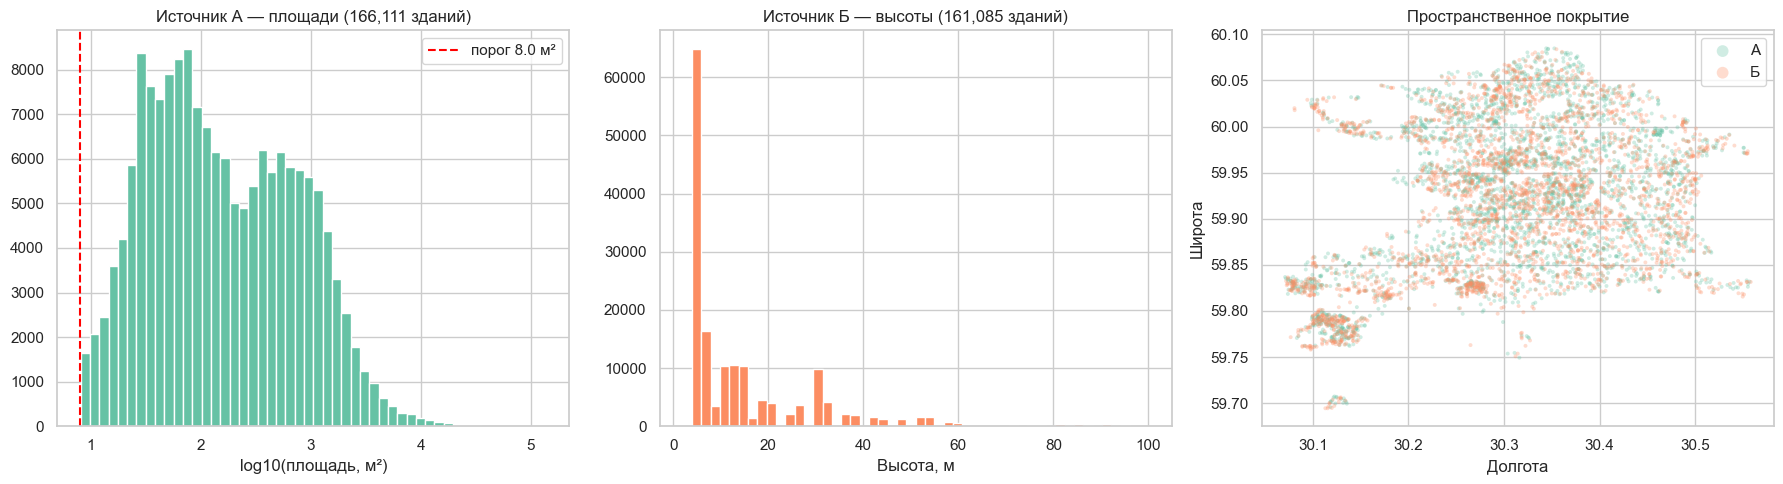

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Распределение площадей А
axes[0].hist(np.log10(gdf_a_clean['area_m2'].clip(lower=1)), bins=50, color='#66c2a5', edgecolor='white')
axes[0].set_xlabel('log10(площадь, м²)')
axes[0].set_title(f'Источник А — площади ({len(gdf_a_clean):,} зданий)')
axes[0].axvline(np.log10(CONFIG['min_area_a']), color='red', ls='--', label=f'порог {CONFIG["min_area_a"]} м²')
axes[0].legend()

# Распределение высот Б
axes[1].hist(gdf_b_clean['height'].dropna().clip(upper=100), bins=50, color='#fc8d62', edgecolor='white')
axes[1].set_xlabel('Высота, м')
axes[1].set_title(f'Источник Б — высоты ({len(gdf_b_clean):,} зданий)')

# Карта покрытия
sample_a = gdf_a_clean.sample(min(3000, len(gdf_a_clean)), random_state=42)
sample_b = gdf_b_clean.sample(min(3000, len(gdf_b_clean)), random_state=42)
ca = sample_a.geometry.centroid
cb = sample_b.geometry.centroid
axes[2].scatter(ca.x, ca.y, s=8, alpha=0.3, label='А', edgecolors='none')
axes[2].scatter(cb.x, cb.y, s=8, alpha=0.3, label='Б', edgecolors='none')
axes[2].set_title('Пространственное покрытие')
axes[2].legend(markerscale=3)
axes[2].set_xlabel('Долгота')
axes[2].set_ylabel('Широта')

plt.tight_layout()
plt.show()

## 4. Сохранение

In [8]:
save_gdf(gdf_a_clean, CONFIG['cleaned_a'])
save_gdf(gdf_b_clean, CONFIG['cleaned_b'])
print("\nОчистка завершена. Файлы готовы для 02_matching.ipynb")

  Сохранено: ./data/cleaned_a.parquet (166111 записей)
  Сохранено: ./data/cleaned_b.parquet (161085 записей)

Очистка завершена. Файлы готовы для 02_matching.ipynb
